# EDA — Buurten (Rotterdam neighbourhood polygons)

This notebook explores the Buurten dataset and prepares it for use
in `03_stratified_sampling.ipynb` as a **geographic sampling constraint**.

The goal is NOT to add buurt as a stratification dimension (that would multiply the
number of strata and reduce per-cell sample size). Instead, we want to use buurt
membership to ensure geographic spread *within* existing strata during sampling.

**Key questions:**
1. What is the file structure and CRS? (notebook 03 needs RD New)
2. What columns are available — which identifies buurt name and code?
3. Is there an existing 'centrum' flag, or do we need to derive one from buurt names?
4. How many intersections fall in each buurt / in centrum vs niet-centrum?
5. What fraction of all intersections are in the centrum?
6. Is the centrum/niet-centrum split balanced enough to matter for sampling?
7. What does the buurt map look like — are the polygons clean and complete?
8. What needs to happen in notebook 03 to use this as a sampling constraint?

## 0. Setup

In [1]:
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

PROJECT_DIR   = r"C:\Users\Thijs\OneDrive\Documents\Studie\EPA\Second_year\Afstuderen\Project\intersections"
BUURTEN_FILE  = os.path.join(PROJECT_DIR, "data", "raw", "Buurten", "Buurten_vlakken.shp")
INTS_FILE     = os.path.join(PROJECT_DIR, "data", "processed", "intersections_merged.gpkg")
CRS_RD        = "EPSG:28992"

print(f"Buurten file : {BUURTEN_FILE}")
print(f"Exists       : {os.path.exists(BUURTEN_FILE)}")
print(f"Intersections: {INTS_FILE}")
print(f"Exists       : {os.path.exists(INTS_FILE)}")

Buurten file : C:\Users\Thijs\OneDrive\Documents\Studie\EPA\Second_year\Afstuderen\Project\intersections\data\raw\Buurten\Buurten_vlakken.shp
Exists       : True
Intersections: C:\Users\Thijs\OneDrive\Documents\Studie\EPA\Second_year\Afstuderen\Project\intersections\data\processed\intersections_merged.gpkg
Exists       : True


## 1. Load and inspect the Buurten file

In [2]:
# Load raw — keep original CRS for inspection, reproject later
buurten = gpd.read_file(BUURTEN_FILE)

print(f"Shape    : {buurten.shape[0]} rows × {buurten.shape[1]} columns")
print(f"CRS      : {buurten.crs}")
print(f"Geometry : {buurten.geom_type.value_counts().to_dict()}")
print(f"\nColumns:")
for col in buurten.columns:
    print(f"  {col}")

Shape    : 91 rows × 19 columns
CRS      : EPSG:28992
Geometry : {'Polygon': 91}

Columns:
  GROEP
  KLASSE
  DGDT_ID
  CODE
  HERKOMST
  STATUS
  NIVO
  INWIN
  GEMEENTE
  GEBIED
  BUURT
  SUBBUURT
  SBTDEEL
  BLOK
  TEKST
  GEBDNAAM
  BUURTNAAM
  LAAG
  geometry


In [3]:
# Show the first rows to understand content
buurten.drop(columns=["geometry"]).head(10)

,GROEP,KLASSE,DGDT_ID,CODE,HERKOMST,STATUS,NIVO,INWIN,GEMEENTE,GEBIED,BUURT,SUBBUURT,SBTDEEL,BLOK,TEKST,GEBDNAAM,BUURTNAAM,LAAG
0,TIR,VB,NaN,15,Onbekend,bestaand/nieuw object,3,20240508,599,15,77,-1,-1,-1,1577,Charlois,Pendrecht,Tirlaag
1,TIR,VB,NaN,15,Onbekend,bestaand/nieuw object,3,20240410,599,8,37,-1,-1,-1,0837,Kralingen-Crooswijk,Oud Crooswijk,Tirlaag
2,TIR,VB,NaN,15,Onbekend,bestaand/nieuw object,3,20240612,599,8,36,-1,-1,-1,0836,Kralingen-Crooswijk,Nieuw Crooswijk,Tirlaag
3,TIR,VB,NaN,15,Onbekend,bestaand/nieuw object,3,20230803,599,10,17,-1,-1,-1,1017,Feijenoord,Kop van Zuid,Tirlaag
4,TIR,VB,NaN,15,Onbekend,bestaand/nieuw object,3,20230126,599,25,40,-1,-1,-1,2540,Rivium,Rivium,Tirlaag
5,TIR,VB,NaN,15,Onbekend,bestaand/nieuw object,3,20240605,599,4,52,-1,-1,-1,0452,Overschie,Noord Kethel,Tirlaag
6,TIR,VB,NaN,15,Onbekend,bestaand/nieuw object,3,20240508,599,15,78,-1,-1,-1,1578,Charlois,Zuiderpark,Tirlaag
7,TIR,VB,NaN,15,Onbekend,bestaand/nieuw object,3,20240530,599,14,44,-1,-1,-1,1444,Prins Alexander,'s-Gravenland,Tirlaag
8,TIR,VB,NaN,15,Onbekend,bestaand/nieuw object,3,20240515,599,10,87,-1,-1,-1,1087,Feijenoord,Feijenoord,Tirlaag
9,TIR,VB,NaN,15,Onbekend,bestaand/nieuw object,3,20240531,599,8,42,-1,-1,-1,0842,Kralingen-Crooswijk,Kralingen Oost,Tirlaag


## 2. Explore the attribute columns

We need to find:
- A buurt **name** column (for labelling)
- A buurt **code** column (for joining)
- Any **wijk** or **deelgemeente** column (useful for centrum classification)
- Whether there are non-Rotterdam rows to filter out

In [4]:
# Print unique values and dtypes for all non-geometry columns
# This helps identify which column to use as name / code / filter
for col in buurten.columns:
    if col == "geometry":
        continue
    nuniq = buurten[col].nunique()
    dtype = buurten[col].dtype
    sample = buurten[col].dropna().unique()[:5].tolist()
    print(f"{col:<25} dtype={str(dtype):<10} nuniq={nuniq:>4}   sample: {sample}")

GROEP                     dtype=str        nuniq=   1   sample: ['TIR']
KLASSE                    dtype=str        nuniq=   1   sample: ['VB']
DGDT_ID                   dtype=float64    nuniq=   0   sample: []
CODE                      dtype=int32      nuniq=   1   sample: [15]
HERKOMST                  dtype=str        nuniq=   1   sample: ['Onbekend']
STATUS                    dtype=str        nuniq=   1   sample: ['bestaand/nieuw object']
NIVO                      dtype=int32      nuniq=   1   sample: [3]
INWIN                     dtype=str        nuniq=  35   sample: ['20240508', '20240410', '20240612', '20230803', '20230126']
GEMEENTE                  dtype=int32      nuniq=   1   sample: [599]
GEBIED                    dtype=int32      nuniq=  21   sample: [15, 8, 10, 25, 4]
BUURT                     dtype=int32      nuniq=  91   sample: [77, 37, 36, 17, 40]
SUBBUURT                  dtype=int32      nuniq=   1   sample: [-1]
SBTDEEL                   dtype=int32      nuniq=   1 

In [5]:
# Check for missing geometry
n_null_geom = buurten.geometry.is_empty.sum() + buurten.geometry.isna().sum()
print(f"Missing or empty geometries: {n_null_geom}")

# Check bounding box to confirm this covers Rotterdam
print(f"\nBounds (original CRS):")
print(buurten.total_bounds)

Missing or empty geometries: 0

Bounds (original CRS):
[ 55500.    428647.44  101032.596 447000.   ]


## 3. Reproject to RD New

All spatial operations in notebook 03 are in RD New (EPSG:28992).
Reproject here and confirm the geometry looks sensible.

CRS after reprojection: EPSG:28992
X range (m): 55500 – 101033
Y range (m): 428647 – 447000


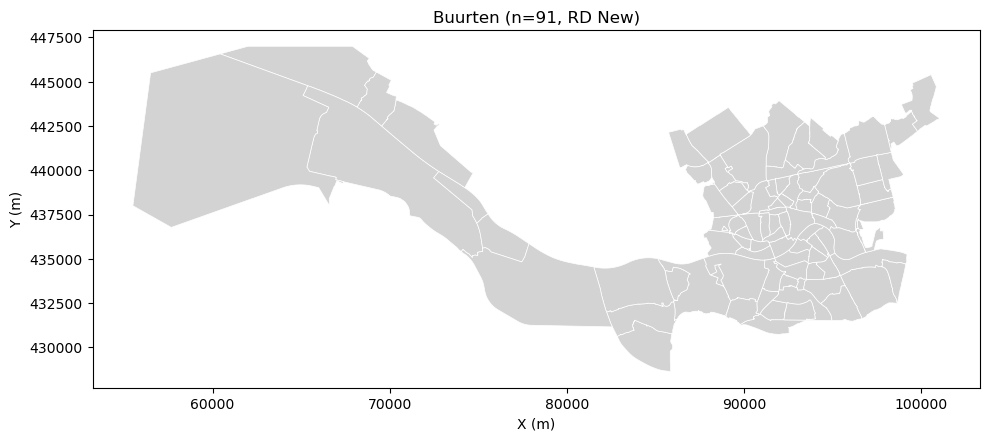

In [6]:
# Reproject to RD New
buurten_rd = buurten.to_crs(CRS_RD)

print(f"CRS after reprojection: {buurten_rd.crs}")
print(f"X range (m): {buurten_rd.total_bounds[0]:.0f} – {buurten_rd.total_bounds[2]:.0f}")
print(f"Y range (m): {buurten_rd.total_bounds[1]:.0f} – {buurten_rd.total_bounds[3]:.0f}")

# Quick map of all buurten
fig, ax = plt.subplots(figsize=(10, 10))
buurten_rd.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.5)
ax.set_title(f"Buurten (n={len(buurten_rd)}, RD New)")
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
plt.tight_layout()
plt.show()

## 4. Identify the centrum area

We want a binary `is_centrum` flag to use as a sampling constraint.
Options:
- Use a dedicated 'centrum' column if it exists
- Filter buurt names containing 'centrum' or a known list of centrum buurten
- Filter by wijk or deelgemeente code

Inspect here, then decide the best approach.

In [7]:
# Search all string columns for values containing 'centrum' (case-insensitive)
# This helps locate the right column for centrum detection
print("Columns with values containing 'centrum':")
for col in buurten_rd.select_dtypes(include="object").columns:
    matches = buurten_rd[col].str.contains("centrum", case=False, na=False)
    if matches.any():
        print(f"  {col}: {buurten_rd.loc[matches, col].unique().tolist()}")

Columns with values containing 'centrum':
  GEBDNAAM: ['Rotterdam Centrum']


C:\Users\Thijs\AppData\Local\Temp\ipykernel_21280\584584278.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in buurten_rd.select_dtypes(include="object").columns:


In [8]:
# GEBDNAAM is the gebied (district) column — "Rotterdam Centrum" is the city centre district
CENTRUM_COLUMN = "GEBDNAAM"
CENTRUM_VALUES = ["Rotterdam Centrum"]

buurten_rd["is_centrum"] = buurten_rd[CENTRUM_COLUMN].isin(CENTRUM_VALUES)
print(f"Centrum buurten : {buurten_rd['is_centrum'].sum()}")
print(f"Niet-centrum    : {(~buurten_rd['is_centrum']).sum()}")

Centrum buurten : 6
Niet-centrum    : 85


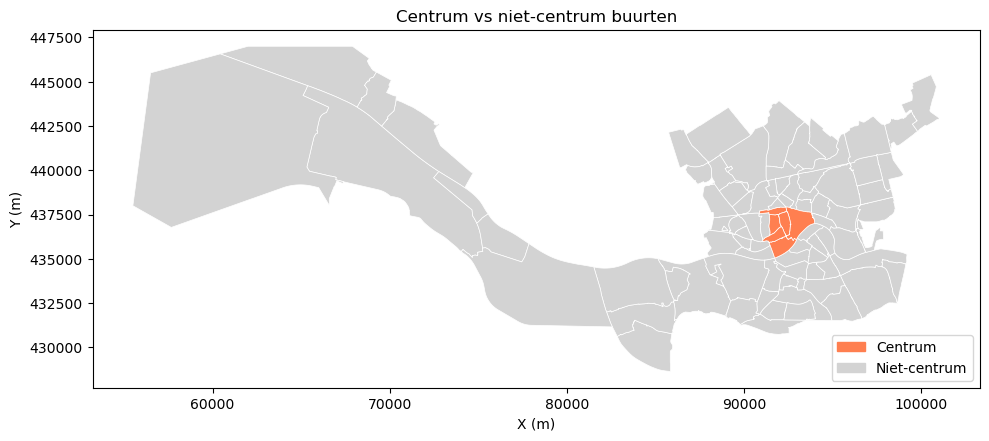

In [9]:
# Visualise centrum vs niet-centrum buurten
fig, ax = plt.subplots(figsize=(10, 10))

# Plot niet-centrum in light grey, centrum in coral
buurten_rd[~buurten_rd["is_centrum"]].plot(
    ax=ax, color="lightgrey", edgecolor="white", linewidth=0.5
)
buurten_rd[buurten_rd["is_centrum"]].plot(
    ax=ax, color="coral", edgecolor="white", linewidth=0.5
)

legend_handles = [
    mpatches.Patch(color="coral",     label="Centrum"),
    mpatches.Patch(color="lightgrey", label="Niet-centrum"),
]
ax.legend(handles=legend_handles, loc="lower right")
ax.set_title("Centrum vs niet-centrum buurten")
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
plt.tight_layout()
plt.show()

## 5. Spatial join: intersections per buurt

Join the NWB intersections to the buurten polygons.
This tells us how many intersections are in each buurt,
and what fraction fall in the centrum.

In [10]:
# Load the NWB intersections and reproject to RD New
intersections = gpd.read_file(INTS_FILE).to_crs(CRS_RD)

print(f"NWB intersections: {len(intersections):,}")
print(f"Buurten          : {len(buurten_rd):,}")

NWB intersections: 4,715
Buurten          : 91


In [11]:
# Spatial join: assign each intersection to the buurt it falls within.
# predicate='within' is used — centroids that fall exactly on a border are
# assigned to one polygon; the small number of such cases is acceptable.
joined = gpd.sjoin(
    intersections[["JTE_ID", "geometry"]],
    buurten_rd[[col for col in buurten_rd.columns if col != "geometry"] + ["geometry"]],
    how="left",
    predicate="within"
)

# How many intersections were matched to a buurt?
n_matched   = joined["index_right"].notna().sum()
n_unmatched = joined["index_right"].isna().sum()
print(f"Intersections matched to a buurt : {n_matched:,}")
print(f"Intersections outside all buurten: {n_unmatched:,}")

# Flag centrum membership on each intersection
if "is_centrum" in joined.columns:
    joined["is_centrum"] = joined["is_centrum"].fillna(False)
    n_centrum    = joined["is_centrum"].sum()
    pct_centrum  = n_centrum / len(intersections) * 100
    print(f"\nCentrum intersections    : {n_centrum:,}  ({pct_centrum:.1f}%)")
    print(f"Niet-centrum intersections: {len(intersections) - n_centrum:,}  ({100 - pct_centrum:.1f}%)")

Intersections matched to a buurt : 4,715
Intersections outside all buurten: 0

Centrum intersections    : 430  (9.1%)
Niet-centrum intersections: 4,285  (90.9%)


In [12]:
# Top 20 buurten by intersection count
# Use the buurt name column identified in section 2 — adjust if needed

# Try to find the buurt name column automatically
name_col_candidates = [c for c in joined.columns if "naam" in c.lower() or "name" in c.lower()]
name_col = name_col_candidates[0] if name_col_candidates else None

if name_col:
    counts = joined[name_col].value_counts().head(20)
    print(f"Top 20 buurten by intersection count (column: {name_col}):")
    print(counts.to_string())
else:
    print("No name column found automatically — inspect joined.columns and set name_col manually.")
    print(f"Available columns: {[c for c in joined.columns if c != 'geometry']}")

Top 20 buurten by intersection count (column: GEBDNAAM):
GEBDNAAM
Charlois                    855
Feijenoord                  782
IJsselmonde                 726
Kralingen-Crooswijk         696
Delfshaven                  563
Noord                       489
Rotterdam Centrum           430
Waalhaven-Eemhaven          120
Spaanse Polder               21
Nieuw Mathenesse             16
Hillegersberg-Schiebroek     12
Overschie                     5


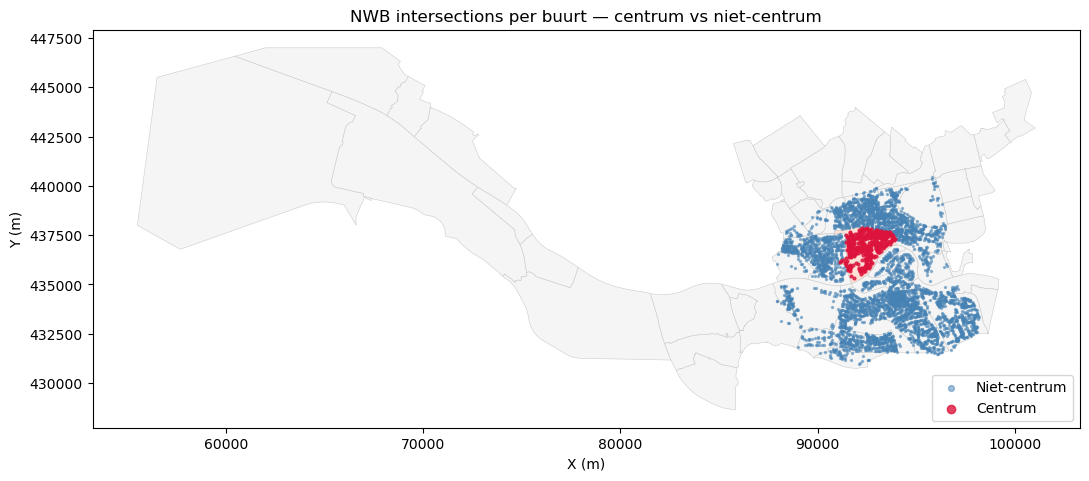

In [13]:
# Map: intersections coloured by centrum membership, on top of buurt polygons
fig, ax = plt.subplots(figsize=(11, 11))

# Buurt outlines as background
buurten_rd.plot(ax=ax, color="whitesmoke", edgecolor="#cccccc", linewidth=0.4)

# Centrum buurten highlighted
buurten_rd[buurten_rd["is_centrum"]].plot(
    ax=ax, color="#ffe0d6", edgecolor="#cccccc", linewidth=0.4
)

# Intersections: centrum in red, niet-centrum in steelblue
if "is_centrum" in joined.columns:
    joined[joined["is_centrum"] == False].plot(
        ax=ax, color="steelblue", markersize=2, alpha=0.5, label="Niet-centrum"
    )
    joined[joined["is_centrum"] == True].plot(
        ax=ax, color="crimson", markersize=4, alpha=0.8, label="Centrum"
    )
else:
    intersections.plot(ax=ax, color="steelblue", markersize=2, alpha=0.5)

ax.legend(loc="lower right", markerscale=3)
ax.set_title("NWB intersections per buurt — centrum vs niet-centrum")
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
plt.tight_layout()
plt.show()

## 6. Check: does the centrum/niet-centrum split vary by stratum?

If the stratified file is already available, check whether centrum intersections
are unevenly distributed across strata. If some strata have very few centrum intersections,
the geographic constraint may not be achievable for every cell.

In [14]:
STRAT_FILE = os.path.join(PROJECT_DIR, "data", "processed", "intersections_stratified.gpkg")

if os.path.exists(STRAT_FILE) and "is_centrum" in joined.columns:
    strat = gpd.read_file(STRAT_FILE).to_crs(CRS_RD)

    # Carry the is_centrum flag over from the spatial join result
    centrum_lookup = joined.set_index("JTE_ID")["is_centrum"]
    strat["is_centrum"] = strat["JTE_ID"].map(centrum_lookup).fillna(False)

    # For each stratum: total count and centrum count
    summary = (
        strat.groupby("stratum")
        .agg(
            total=("JTE_ID", "count"),
            centrum=("is_centrum", "sum")
        )
        .assign(pct_centrum=lambda df: df["centrum"] / df["total"] * 100)
        .sort_values("stratum")
    )

    print("Centrum intersections per stratum:")
    print("-" * 55)
    print(f"{'Stratum':<22} {'Total':>7} {'Centrum':>8} {'%':>7}")
    print("-" * 55)
    for stratum, row in summary.iterrows():
        flag = "  ⚠ no centrum" if row["centrum"] == 0 else ""
        print(f"{stratum:<22} {row['total']:>7.0f} {row['centrum']:>8.0f} {row['pct_centrum']:>6.1f}%{flag}")
    print("-" * 55)
else:
    if not os.path.exists(STRAT_FILE):
        print("intersections_stratified.gpkg not found — run notebook 03 first.")
    else:
        print("is_centrum column not available — complete section 4 first.")

Centrum intersections per stratum:
-------------------------------------------------------
Stratum                  Total  Centrum       %
-------------------------------------------------------
4+_VRI                     168       41   24.4%
4+_geen_voorrang           699       67    9.6%
4+_voorrang                384       34    8.9%
T_VRI                       18        3   16.7%
T_geen_voorrang           2894      222    7.7%
T_voorrang                 552       63   11.4%
-------------------------------------------------------


## 7. Summary — how to use this in notebook 03

Based on the above, what changes are needed in notebook 03.

In [15]:
n_centrum_ints   = int(joined["is_centrum"].sum()) if "is_centrum" in joined.columns else "?"
pct_centrum_ints = n_centrum_ints / len(intersections) * 100 if isinstance(n_centrum_ints, int) else "?"

print("=" * 65)
print("SUMMARY: How to integrate buurten into notebook 03")
print("=" * 65)
print()
print("APPROACH: geographic sampling CONSTRAINT, not a stratum dimension.")
print("  This avoids multiplying strata while ensuring geographic spread.")
print()
print("1. FILE")
print(f"   Buurten file : {os.path.relpath(BUURTEN_FILE, PROJECT_DIR)}")
print(f"   CRS          : {buurten.crs}  →  reproject to RD New before join")
print()
print("2. COLUMN TO USE")
print(f"   Centrum column : {CENTRUM_COLUMN}")
print(f"   Centrum values : {CENTRUM_VALUES}")
print()
print("3. INTERSECTION COVERAGE")
print(f"   Total intersections : {len(intersections):,}")
print(f"   Centrum             : {n_centrum_ints}  ({pct_centrum_ints:.1f}% of total)")
print(f"   Niet-centrum        : {len(intersections) - n_centrum_ints if isinstance(n_centrum_ints, int) else '?'}")
print()
print("4. WHAT TO DO IN NOTEBOOK 03")
print("   - Add BUURTEN_FILE path to config cell")
print("   - After assigning strata: spatial join intersections → buurten → is_centrum flag")
print("   - In the sampling step: within each stratum, draw proportionally from")
print("     centrum and niet-centrum based on their share within that stratum cell")
print("   - Do NOT add is_centrum as a stratum dimension column")
print()
print("5. EDGE CASE")
print("   If any stratum cell has 0 centrum intersections:")
print("   → skip the centrum constraint for that cell (sample freely from it)")

SUMMARY: How to integrate buurten into notebook 03

APPROACH: geographic sampling CONSTRAINT, not a stratum dimension.
  This avoids multiplying strata while ensuring geographic spread.

1. FILE
   Buurten file : data\raw\Buurten\Buurten_vlakken.shp
   CRS          : EPSG:28992  →  reproject to RD New before join

2. COLUMN TO USE
   Centrum column : GEBDNAAM
   Centrum values : ['Rotterdam Centrum']

3. INTERSECTION COVERAGE
   Total intersections : 4,715
   Centrum             : 430  (9.1% of total)
   Niet-centrum        : 4285

4. WHAT TO DO IN NOTEBOOK 03
   - Add BUURTEN_FILE path to config cell
   - After assigning strata: spatial join intersections → buurten → is_centrum flag
   - In the sampling step: within each stratum, draw proportionally from
     centrum and niet-centrum based on their share within that stratum cell
   - Do NOT add is_centrum as a stratum dimension column

5. EDGE CASE
   If any stratum cell has 0 centrum intersections:
   → skip the centrum constraint fo